## Init

In [1]:
import numpy as np
from tqdm.auto import trange
from scipy.linalg import orthogonal_procrustes
from scipy.optimize import quadratic_assignment
from sklearn.cluster import KMeans

import torch
import torch.nn.functional as F

def cos_sim_matrix(X, Y):
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X)
    if isinstance(Y, np.ndarray):
        Y = torch.from_numpy(Y)
    X_norm = X / X.norm(dim=-1, keepdim=True)
    Y_norm = Y / Y.norm(dim=-1, keepdim=True)
    return X_norm @ Y_norm.T

def tensor(x):
    return torch.tensor(x).float()

def N(X, dim=-1, **kwargs):
    return F.normalize(X, dim=dim, **kwargs)

def sim(X, Y):
    X, Y = tensor(X), tensor(Y)
    # center the tensors
    # TODO: centering probably not necessary, and perhaps not implemented correctly, might need transpose somewhere and stuff
    H = torch.eye(len(X), device=X.device) - (1/len(X)) * torch.ones((len(X), len(X)), device=X.device)
    return H @ X @ Y.T @ H

def train_orthogonal_linear(X, Y):
    solution, _ = orthogonal_procrustes(X, Y)
    return tensor(solution)

def eval_score(X_eval, Y_eval, W, backward=False):
    if backward:
        return torch.round(torch.cosine_similarity(X_eval, Y_eval @ W.T, dim=-1).mean(), decimals=2).item()
    else:
        return torch.round(torch.cosine_similarity(X_eval @ W, Y_eval, dim=-1).mean(), decimals=2).item()

def top_cosine_similarity(X: torch.Tensor, Y: torch.Tensor, k=1) -> float:
    sims = cos_sim_matrix(X, Y)
    topk = sims.topk(k=k, dim=-1).values
    return torch.round(topk.mean(), decimals=2).item()

In [2]:
from umap import UMAP
import matplotlib.pyplot as plt

# Transform X_eval using the learned linear transformation W
def plot_umap(X, Y):
    Y_np = Y.cpu().numpy()

    # Combine the data for UMAP
    combined_data = np.vstack([X, Y_np])

    # Apply UMAP dimensionality reduction
    reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
    embedding = reducer.fit_transform(combined_data)

    # Split the embedding back into X and Y components
    n_samples = len(X)
    X_embedding = embedding[:n_samples]     # type: ignore
    Y_embedding = embedding[n_samples:]     # type: ignore

    # Compute cosine similarity matrix
    cos_sims = cos_sim_matrix(X, Y)

    # Create the plot
    plt.figure(figsize=(12, 8))
    plt.scatter(X_embedding[:, 0], X_embedding[:, 1], alpha=0.6, c='blue', label='X @ W (Transformed)', s=20)       # type: ignore
    plt.scatter(Y_embedding[:, 0], Y_embedding[:, 1], alpha=0.6, c='red', label='Y (Target)', s=20)                 # type: ignore

    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.title(f"Average Cosine Similarity: {cos_sims.diagonal().mean():.4f}")
    plt.show()

In [3]:
import torch

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

## Shortcut - Load from Saved Embeddings

In [4]:
import torch

nq_stella, nq_e5 = torch.load('embeddings/nq/stella.pt'), torch.load('embeddings/nq/e5.pt')
trec_stella, trec_e5 = torch.load('embeddings/trec-covid-corpus/stella.pt'), torch.load('embeddings/trec-covid-corpus/e5.pt')

In [5]:
nq_stella, nq_e5 = N(nq_stella), N(nq_e5)
trec_stella, trec_e5 = N(trec_stella), N(trec_e5)

In [ ]:
def train_test_split(
    embeddings_x1: torch.Tensor, embeddings_y1: torch.Tensor,  # Data source 1 (e.g., nq)
    embeddings_x2: torch.Tensor, embeddings_y2: torch.Tensor,  # Data source 2 (e.g., trec)
    num_train_samples: int,
    num_test_samples: int,
    source1_ratio: float = 0.5,  # Ratio of data source 1 in training set only
):
    """
    Splits embeddings from two data sources into training and testing sets.
    - Training sets: Independently shuffled, NO correspondence between X_train and Y_train
                     Mix of both data sources controlled by source1_ratio
    - Test sets: 1:1 matched (same indices used for X and Y), always 50/50 split
    
    Args:
        embeddings_x1, embeddings_y1: First data source (e.g., nq stella/e5)
        embeddings_x2, embeddings_y2: Second data source (e.g., trec stella/e5)
        num_train_samples: Total number of samples for each training set
        num_test_samples: Total number of samples for evaluation (1:1 matched, always 50/50)
        source1_ratio: Proportion of training data from source 1 (0.0 to 1.0)
    """
    assert 0.0 <= source1_ratio <= 1.0, "source1_ratio must be between 0 and 1"
    
    # Calculate samples from each source for training
    num_train_from_source1 = int(num_train_samples * source1_ratio)
    num_train_from_source2 = num_train_samples - num_train_from_source1
    
    # Test set is always 50/50
    num_test_from_source1 = num_test_samples // 2
    num_test_from_source2 = num_test_samples - num_test_from_source1
    
    # Reserve test samples from both sources (1:1 matched - same indices for X and Y)
    assert num_test_from_source1 <= len(embeddings_x1), "Not enough samples in source 1 for test set"
    assert num_test_from_source2 <= len(embeddings_x2), "Not enough samples in source 2 for test set"
    
    X_test_s1 = embeddings_x1[:num_test_from_source1]
    Y_test_s1 = embeddings_y1[:num_test_from_source1]
    X_test_s2 = embeddings_x2[:num_test_from_source2]
    Y_test_s2 = embeddings_y2[:num_test_from_source2]
    
    # Remaining data available for training
    remaining_x1 = embeddings_x1[num_test_from_source1:]
    remaining_y1 = embeddings_y1[num_test_from_source1:]
    remaining_x2 = embeddings_x2[num_test_from_source2:]
    remaining_y2 = embeddings_y2[num_test_from_source2:]
    
    assert num_train_from_source1 <= len(remaining_x1), f"Not enough samples in source 1 for training (need {num_train_from_source1}, have {len(remaining_x1)})"
    assert num_train_from_source2 <= len(remaining_x2), f"Not enough samples in source 2 for training (need {num_train_from_source2}, have {len(remaining_x2)})"
    
    # Sample from source 1 (independently for X and Y)
    indices_x1 = torch.randperm(len(remaining_x1))[:num_train_from_source1]
    indices_y1 = torch.randperm(len(remaining_y1))[:num_train_from_source1]
    X_train_s1 = remaining_x1[indices_x1]
    Y_train_s1 = remaining_y1[indices_y1]
    
    # Sample from source 2 (independently for X and Y)
    indices_x2 = torch.randperm(len(remaining_x2))[:num_train_from_source2]
    indices_y2 = torch.randperm(len(remaining_y2))[:num_train_from_source2]
    X_train_s2 = remaining_x2[indices_x2]
    Y_train_s2 = remaining_y2[indices_y2]
    
    # Combine and shuffle training data
    X_train = torch.cat([X_train_s1, X_train_s2])
    Y_train = torch.cat([Y_train_s1, Y_train_s2])
    shuffle_x = torch.randperm(len(X_train))
    shuffle_y = torch.randperm(len(Y_train))
    X_train = X_train[shuffle_x]
    Y_train = Y_train[shuffle_y]
    
    # Combine test data (maintain 1:1 matching by using same shuffle for X and Y)
    X_test = torch.cat([X_test_s1, X_test_s2])
    Y_test = torch.cat([Y_test_s1, Y_test_s2])
    shuffle_test = torch.randperm(len(X_test))
    X_test = X_test[shuffle_test]
    Y_test = Y_test[shuffle_test]  # Same shuffle to maintain 1:1 correspondence

    return X_train, Y_train, X_test, Y_test

In [7]:
X_train, Y_train, X_eval, Y_eval = train_test_split(
    nq_stella, nq_e5,      # Source 1: nq
    trec_stella, trec_e5,  # Source 2: trec
    num_train_samples=12000,
    num_test_samples=1000,
    source1_ratio=0.5,     # 50% nq, 50% trec in training
)

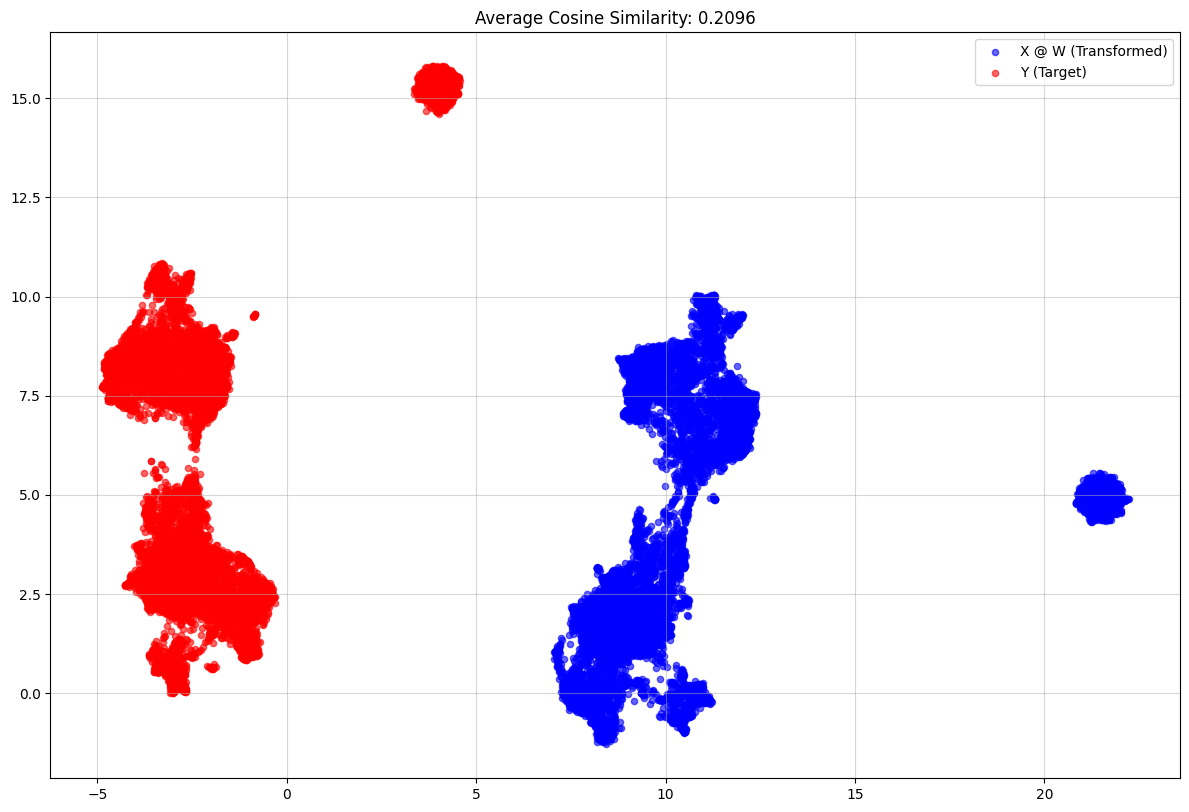

In [8]:
plot_umap(X_train, Y_train)

## Step 1: Match Anchors

In [9]:
def aligned_centroids(X_train, Y_train, n_runs=300, n_clusters=50, method='2opt', subsample=None, verbose=True):
    if subsample is not None:
        X_train, Y_train = X_train[torch.randperm(len(X_train))[:subsample]], Y_train[torch.randperm(len(Y_train))[:subsample]]

    clusterer1 = KMeans(n_clusters=n_clusters)
    clusterer1.fit(X_train)
    clusterer2 = KMeans(n_clusters=n_clusters)
    clusterer2.fit(Y_train)
    centers1, centers2 = clusterer1.cluster_centers_, clusterer2.cluster_centers_
    kernel1 =  sim(centers1, centers1).float()
    kernel2 = sim(centers2, centers2).float()

    quad = None
    # need to re-run the QAP a few times because it's not very good at finding the global optimum (even 2opt)
    for i in trange(n_runs, leave=False, disable=not verbose):
        new_quad = quadratic_assignment(kernel1, kernel2, method=method, options={'maximize': True})
        if quad is None or quad.fun < new_quad.fun:
            quad = new_quad
    centers2 = centers2[quad.col_ind] # type: ignore
    return tensor(centers1), tensor(centers2)

In [10]:
from warnings import filterwarnings

filterwarnings("ignore", category=FutureWarning)

all_centers1, all_centers2 = [], []
for i in trange(30):
    centers1, centers2 = aligned_centroids(X_train, Y_train, subsample=10_000, n_clusters=20, n_runs=30, method='2opt', verbose=False)
    all_centers1.append(centers1)
    all_centers2.append(centers2)

  0%|          | 0/30 [00:00<?, ?it/s]

In [11]:
all_centers1 = torch.cat(all_centers1, dim=0)
all_centers2 = torch.cat(all_centers2, dim=0)

In [12]:
sim1 = cos_sim_matrix(X_train, all_centers1)
sim2 = cos_sim_matrix(Y_train, all_centers2)
sim_similarity = cos_sim_matrix(sim1, sim2)

In [13]:
k = 50
top_similar = sim_similarity.topk(dim=-1, k=k).indices

In [14]:
coefs =  torch.ones(k) / k # N(1 / (1 + torch.arange(k))**.5, p=1) #
Y_matched = Y_train[top_similar].transpose(-1, -2) @ coefs

## Step 3: Refinement

### Refine-1: Iterative Closest Point Average

In [ ]:
# depending on how well the previous step went, you might want to increase/decrease this
# of course, in reality you are not privy to the eval score..

def refine_1(n_iters=100, k=50, n_samples=1000):
    W = train_orthogonal_linear(X_train, Y_matched)
    
    for _ in trange(n_iters):
        sample_points = X_train[torch.randperm(len(X_train))[:n_samples]]
        sample_similarities = cos_sim_matrix(sample_points @ W, Y_train)
        neighbors = sample_similarities.topk(dim=-1, k=k).indices
        sample_matched = Y_train[neighbors].mean(dim=1)
        
        W_new = train_orthogonal_linear(sample_points, sample_matched)
        W = 0.5 * W + 0.5 * W_new ## Why this way?
    return W

In [16]:
W = refine_1(n_iters=50, k=50)

  0%|          | 0/50 [00:00<?, ?it/s]

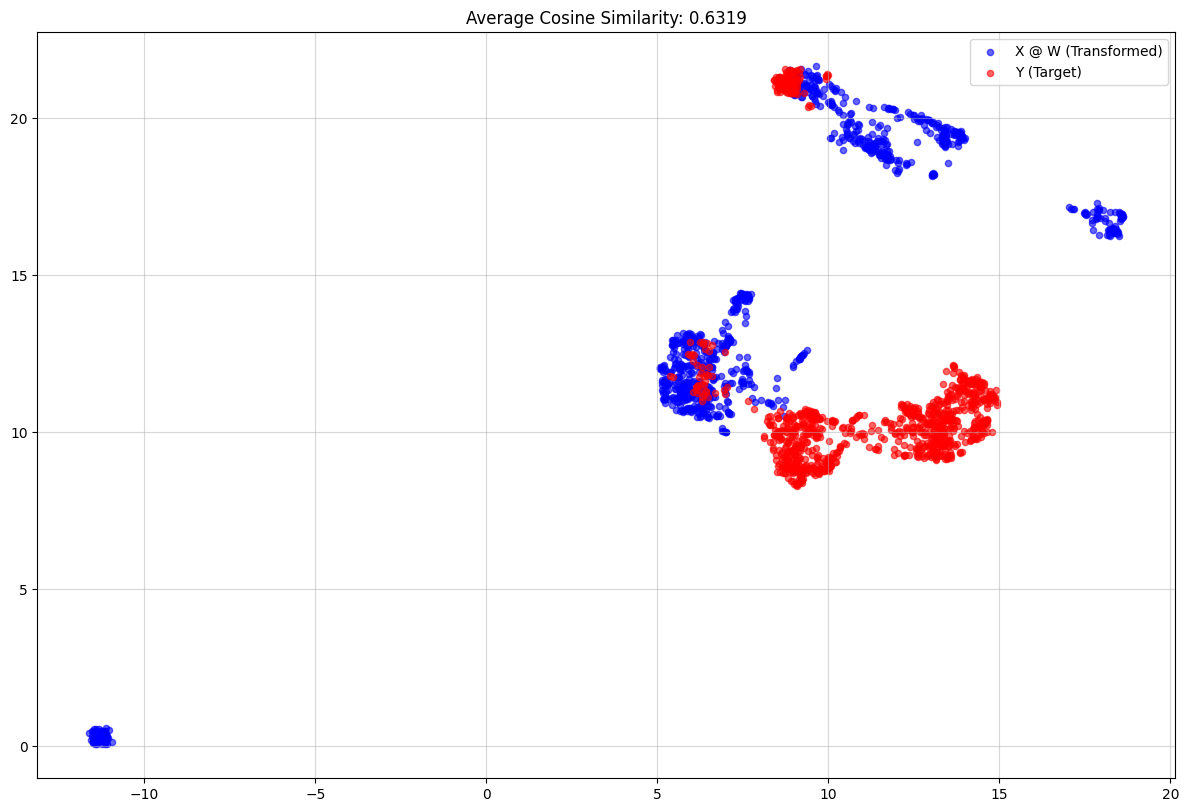

In [17]:
plot_umap(X_eval @ W, Y_eval)

### Refine-2: Cluter-Based Alignment Correction

In [18]:
def refine_2(W: torch.Tensor, n_iters=2, n_clusters=500):
    for _ in trange(n_iters):
        kmeans1 = KMeans(n_clusters=n_clusters).fit(X_train)
        centers1 = tensor(kmeans1.cluster_centers_)

        kmeans2 = KMeans(n_clusters=n_clusters, init=centers1 @ W).fit(Y_train) # type: ignore
        centers2 = tensor(kmeans2.cluster_centers_)

        # print('Self consistency of KMeans', torch.cosine_similarity(centers1 @ W, centers2, dim=-1).mean())

        W_new = train_orthogonal_linear(centers1, centers2)
        W = 0.5 * W + 0.5 * W_new
        # print('Eval score:', eval_score(X_eval, Y_eval, W))
    return W

## Final Evaluation

In [19]:
W_raw = refine_1(n_iters=100, k=50, n_samples=1000)

  0%|          | 0/100 [00:00<?, ?it/s]

In [20]:
W = refine_2(W_raw, n_iters=2, n_clusters=500)

  0%|          | 0/2 [00:00<?, ?it/s]

In [21]:
def rank(X):
    return torch.argsort(torch.argsort(X, dim=-1), dim=-1)

In [22]:
ranks = rank(cos_sim_matrix(X_eval @ W, Y_eval)).diagonal()

In [23]:
print("Top-1 Accuracy:", (len(X_eval) - 1 == ranks).float().mean().item()) # type: ignore
print("Average Rank:", len(X_eval) - ranks.float().mean().item()) # type: ignore
print("Average cos sim @ top 1:", top_cosine_similarity(X_eval @ W, Y_eval, k=1))

Top-1 Accuracy: 0.004000000189989805
Average Rank: 607.6900024414062
Average cos sim @ top 1: 0.800000011920929


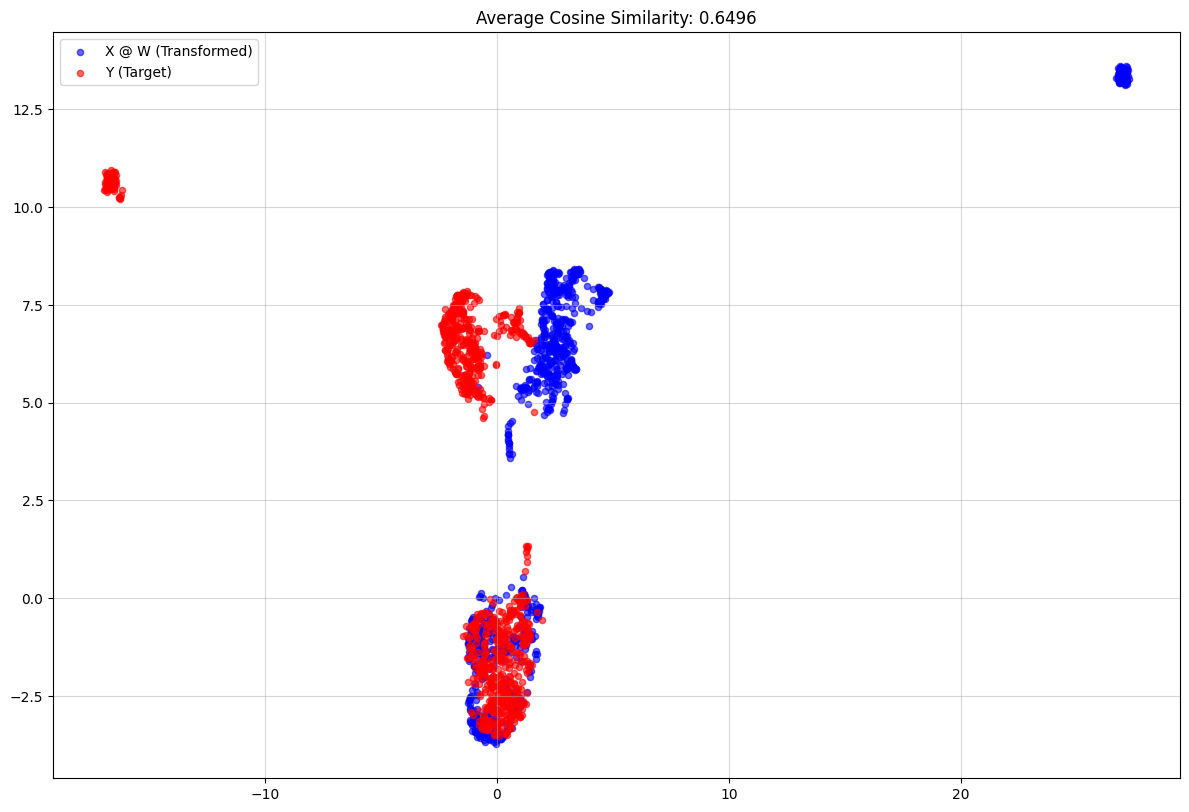

In [24]:
plot_umap(X_eval @ W, Y_eval)